# Microscope Model: Gaussian Beam Propagation

Load the microscope from TOML, build components for a chosen mode,
propagate Gaussian beams through the column, and visualise both the
ray trajectories and the detector-plane intensity.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_MEM_FRACTION"] = "0.1"

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from temgym_core.microscope_model import MicroscopeModel
from temgym_core.source import point_source_wave
from temgym_core.components import SigmoidAperture, Detector, Plane
from temgym_core.run import run_iter_vmapped
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
import jax 

%matplotlib widget
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")

if jax.default_backend() != "gpu":
    raise RuntimeError(f"GPU backend not available. Current backend: {jax.default_backend()}")

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())



JAX backend: gpu
Devices: [CudaDevice(id=0)]


## 1. Load the model and choose an operating point

In [2]:
model = MicroscopeModel.from_toml(
    "microscope.toml",
    mode_names={
        "illumination.parallel": "spot",
        "imaging.magnification": "mag",
        "imaging.diffraction": "diff",
    },
    mode_defaults={"spot": {"Obj_prefield": 1.0}},
)

# The microscope always runs in a condenser mode + an imaging mode simultaneously.
operating_modes = {"spot": 3.0, "mag": 100_000.0}

print(f"Voltage   : {model.voltage/1e3:.0f} kV")
print(f"Lenses    : {[l.name for l in model.lenses]}")
print(f"Deflectors: {[d.name for d in model.deflectors]}")
print(f"Modes     : {list(model.modes.keys())}")
print(f"Active    : {operating_modes}")

Voltage   : 200 kV
Lenses    : ['CL1', 'CL3', 'C_mini', 'Obj_prefield', 'Obj_post', 'IL1', 'IL2', 'IL3', 'PL1']
Deflectors: ['CL12_deflector']
Modes     : ['spot', 'mag', 'diff']
Active    : {'spot': 3.0, 'mag': 100000.0}


## 2. Build the optical column

In [3]:
# Optical components from combined condenser + imaging modes
optics = list(model.build_components(operating_modes))

# Aperture from the TOML auxiliary data
ap_info = model.auxiliary["apertures"]["C_aperture"]
aperture = SigmoidAperture(
    radius=ap_info["radii"][2],  # 30 um aperture
    edge_width=ap_info["radii"][2] * 0.05,
    sharpness=10.0,
    z=ap_info["z"],
)

# Detector from the TOML auxiliary data
det_info = model.auxiliary["detector"]
detector = Detector(
    z=det_info["z"],
    pixel_size=(det_info["pixel_size"], det_info["pixel_size"]),
    shape=(det_info["shape"][0], det_info["shape"][1]),
)

# Sample from the TOML auxiliary data
samp_info = model.auxiliary["sample"]
sample = Plane(z=samp_info["z"])

# Full column: optics + aperture + sample + detector, sorted by z
all_components = optics + [aperture, sample, detector]
# Build a z -> name lookup from the model config
z_to_name = {float(l.z_position): l.name for l in model.lenses}
z_to_name[float(aperture.z)] = ap_info.get("name", "C aperture")
z_to_name[float(sample.z)] = samp_info.get("name", "Sample")
z_to_name[float(detector.z)] = det_info.get("name", "Detector")
for d in model.deflectors:
    z_to_name[float(d.z_position)] = d.name

# Sort and build parallel names list
column = sorted(all_components, key=lambda c: float(c.z))
column_names = [z_to_name.get(float(c.z), type(c).__name__) for c in column]

for c, cname in zip(column, column_names):
    current = f"I={float(c.current):.4f} A" if hasattr(c, 'current') else ""
    print(f"  z = {float(c.z):.4f} m  {cname:25s} {current}")

  z = 0.2000 m  CL1                       I=0.7264 A
  z = 0.2400 m  CL3                       I=0.7917 A
  z = 0.2500 m  C aperture                
  z = 0.2900 m  CL12_deflector            
  z = 0.3000 m  C_mini                    I=1.0000 A
  z = 0.3200 m  Obj_prefield              I=1.0000 A
  z = 0.3250 m  Sample                    
  z = 0.3273 m  Obj_post                  I=-2.4725 A
  z = 0.5297 m  IL1                       I=2.6137 A
  z = 0.6068 m  IL2                       I=1.9160 A
  z = 0.6693 m  IL3                       I=1.7816 A
  z = 0.7243 m  PL1                       I=-3.1163 A
  z = 1.0437 m  Detector                  


## 3. Create the input Gaussian beam

In [4]:
z_source = model.auxiliary.get("z_source", 0.0)
voltage = model.voltage

beam_in = point_source_wave(
    n=10000,                  # 10000 Gaussian sub-beams
    half_angle=0.5e-3,      # 0.5 mrad semi-convergence
    waist=100e-9,            # 100 nm initial waist
    voltage=voltage,
    z0=z_source,
)

n_rays = beam_in.x.shape[0]
print(f"Input beam: {n_rays} Gaussian sub-beams at z = {z_source} m")

Input beam: 10000 Gaussian sub-beams at z = 0.0 m


## 4. Propagate and collect ray trajectories

In [5]:
def trace_column(beam, components):
    """Propagate beam through components, recording (z, x) at each step.

    Uses jax.vmap internally so each component sees a single ray.
    Returns zs, xs arrays for plotting, plus a dict mapping each component
    to its (before, after) beam states for evaluation at any plane.
    """
    zs = [float(beam.z[0])]
    xs = [np.array(beam.x)]

    # run_iter_vmapped returns 2 rays per component: drift-to, then interact
    step_rays = run_iter_vmapped(beam, components)
    beams = {}
    for i, ray in enumerate(step_rays):
        zs.append(float(ray.z[0]))
        xs.append(np.array(ray.x))
        # Even indices = arrived at component (before), odd = after interaction
        comp_idx = i // 2
        if i % 2 == 0:
            beams[comp_idx] = {"before": ray}
        else:
            beams[comp_idx]["after"] = ray

    beam_out = step_rays[-1]
    return np.array(zs), np.stack(xs, axis=0), beam_out, beams


zs, xs, beam_out, beams = trace_column(beam_in, column)
print(f"Traced {len(zs)} steps, final z = {zs[-1]:.4f} m")

# Map component labels to their index in the column for easy lookup
comp_index = {name: i for i, name in enumerate(column_names)}
print("Component index:", comp_index)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape float64[]
The problem arose with the `float` function. If trying to convert the data type of a value, try using `x.astype(float)` or `jnp.array(x, float)` instead.
The error occurred while tracing the function _run_iter_outputs at /home/dl277493/Documents/Code/TemGymCore/src/temgym_core/run.py:157 for jit. This concrete value was not available in Python because it depends on the value of the argument components[0][7].

See https://docs.jax.dev/en/latest/errors.html#jax.errors.ConcretizationTypeError

## 5. Ray trajectory plot

In [ ]:
def visualise_beam(beam, pixel_size=1e-6, shape=(512, 512), *,
                   aperture_radius=None, title="", ax=None, scale="um"):
    """Evaluate Gaussian beam intensity on a grid and display it.

    Parameters
    ----------
    beam : GaussianBeam
        Beam state at the plane to visualise.
    pixel_size : float
        Grid pixel size in metres.
    shape : tuple
        Grid shape (ny, nx).
    aperture_radius : float or None
        If given, draw a circle at this radius (metres).
    title : str
        Plot title.
    ax : matplotlib Axes or None
        Axes to draw on; creates a new figure if None.
    scale : str
        "um" for microns, "mm" for millimetres in axis labels.
    """
    grid = Detector(
        z=float(beam.z[0]),
        pixel_size=(pixel_size, pixel_size),
        shape=shape,
    )
    field = evaluate_gaussians_gpu_kernel_wrapper(beam, grid)
    intensity = np.array(jnp.abs(field) ** 2)

    s = {"um": 1e6, "mm": 1e3}[scale]
    half_y = shape[0] / 2 * pixel_size * s
    half_x = shape[1] / 2 * pixel_size * s
    extent = [-half_x, half_x, -half_y, half_y]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    im = ax.imshow(intensity, extent=extent, origin="lower", cmap="inferno")
    ax.set_xlabel(f"x [{scale}]")
    ax.set_ylabel(f"y [{scale}]")
    ax.set_title(title or f"z = {float(beam.z[0]):.4f} m")
    ax.figure.colorbar(im, ax=ax, label="Intensity [a.u.]", shrink=0.8)

    if aperture_radius is not None:
        circle = plt.Circle((0, 0), aperture_radius * s,
                            fill=False, edgecolor="cyan", linewidth=1.5, linestyle="--")
        ax.add_patch(circle)

    return ax

## 5b. Beam at the aperture plane (before & after)

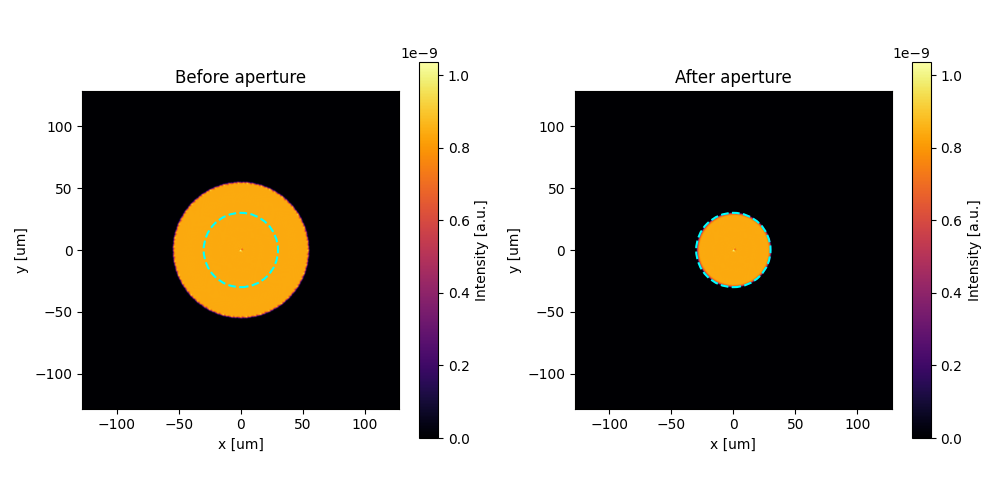

In [ ]:
ap_idx = comp_index[ap_info["name"]]
beam_before_ap = beams[ap_idx]["before"]
beam_after_ap  = beams[ap_idx]["after"]
ap_radius = float(aperture.radius)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

visualise_beam(
    beam_before_ap,
    pixel_size=0.5e-6,
    shape=(512, 512),
    aperture_radius=ap_radius,
    title="Before aperture",
    ax=ax1,
)
visualise_beam(
    beam_after_ap,
    pixel_size=0.5e-6,
    shape=(512, 512),
    aperture_radius=ap_radius,
    title="After aperture",
    ax=ax2,
)

plt.tight_layout()

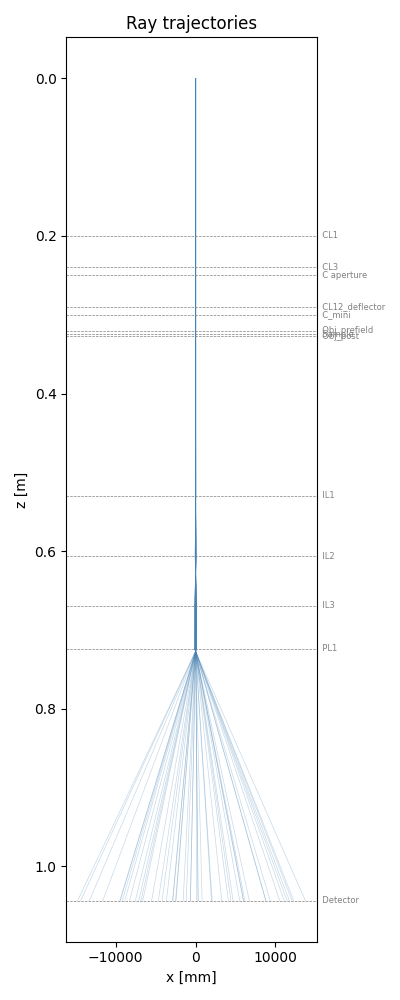

In [ ]:
def plot_column(zs, xs, components, names=None, max_rays=50, ax=None):
    """Minimal ray trajectory visualisation along the column."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 10))

    # Plot ray lines (subsample if many)
    n_rays = xs.shape[1]
    stride = max(1, n_rays // max_rays)
    for j in range(0, n_rays, stride):
        ax.plot(xs[:, j] * 1e3, zs, color="steelblue", alpha=0.3, lw=0.5)

    # Mark components
    for i, c in enumerate(components):
        z_c = float(c.z)
        label = names[i] if names else type(c).__name__
        ax.axhline(z_c, color="gray", ls="--", lw=0.5)
        ax.text(
            ax.get_xlim()[1], z_c, f"  {label}",
            va="center", fontsize=6, color="gray",
        )

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("z [m]")
    ax.invert_yaxis()
    ax.set_title("Ray trajectories")
    plt.tight_layout()
    return ax


plot_column(zs, xs, column, names=column_names);

## 6. Evaluate Gaussian intensity at the detector

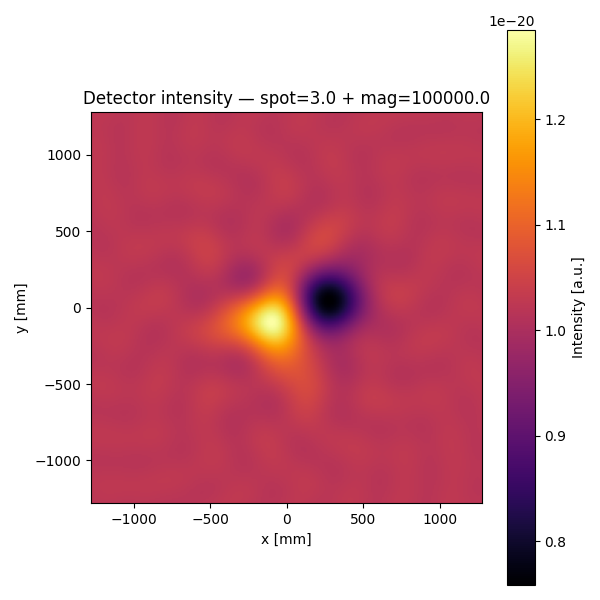

In [9]:
field = evaluate_gaussians_gpu_kernel_wrapper(beam_out, detector)
intensity = jnp.abs(field) ** 2

extent_mm = (
    np.array([
        -det_info["shape"][1] / 2,
         det_info["shape"][1] / 2,
        -det_info["shape"][0] / 2,
         det_info["shape"][0] / 2,
    ])
    * det_info["pixel_size"]
    * 1e3  # to mm
)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    np.array(intensity),
    extent=extent_mm,
    origin="lower",
    cmap="inferno",
)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
mode_str = " + ".join(f"{k}={v}" for k, v in operating_modes.items())
ax.set_title(f"Detector intensity — {mode_str}")
fig.colorbar(im, ax=ax, label="Intensity [a.u.]")
plt.tight_layout();

## 7. ABCD transfer-matrix profile in Diffraction Mode

Selected camera length: 0.554941 m

Sample -> Detector transfer (diffraction, CL=0.5549 m):
  A = -2.562939e-09  (should be ~0)
  B = -0.554941 m (should match CL = +0.554941 m)
  |B|/CL = 1.000000  (should be 1.0)


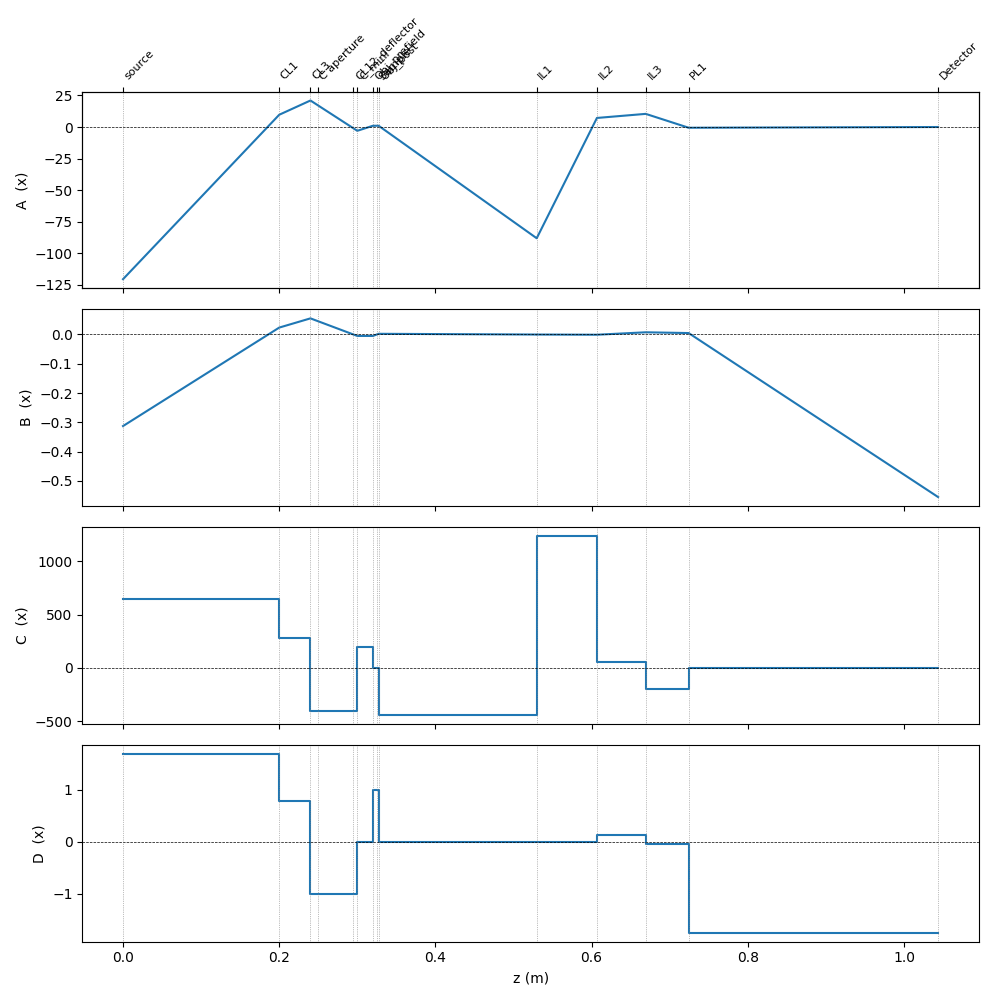

In [33]:
from temgym_core.run import solve_model_with_z
from temgym_core.plotting import plot_abcd_profile, _rotation_matrix_5x5
from temgym_core.ray import Ray
import numpy as np

# Switch to a diffraction mode and choose the target camera length [m]
# Pick the CL closest to 0.5 m from the available modes
mode_diff = model.modes["diff"]
cl_values = np.asarray(mode_diff.control_values, dtype=float)
camera_length = float(cl_values[np.argmin(np.abs(cl_values - 0.5))])
print(f"Selected camera length: {camera_length:.6f} m")

operating_modes_diff = {"spot": operating_modes["spot"], "diff": camera_length}
optics_diff = list(model.build_components(operating_modes_diff))

# Rebuild the full column and names for this mode
all_components_diff = optics_diff + [aperture, sample, detector]
column_diff = sorted(all_components_diff, key=lambda c: float(c.z))
column_diff_names = [z_to_name.get(float(c.z), type(c).__name__) for c in column_diff]

# Single on-axis ray at the source for the Jacobian computation
ray0 = Ray(x=0.0, y=0.0, dx=0.0, dy=0.0, z=z_source, pathlength=0.0, voltage=voltage)

z_prof, M_cum, step_labels, rot = solve_model_with_z(ray0, column_diff, names=column_diff_names)

# --- Relative to the sample plane in diffraction mode ---
sample_name = samp_info.get("name", "Sample")
fig1, axes1 = plot_abcd_profile(
    z_prof, M_cum, labels=step_labels, rotation=rot,
    reference=sample_name,
)
fig1.suptitle(
    f"ABCD in diffraction mode (CL={camera_length:.4f} m) relative to {sample_name} (co-rotating frame)",
    y=1.02,
 );

# --- Check transfer from sample to detector: A -> 0 and B relation in diffraction mode ---
M_corot = np.stack([
    _rotation_matrix_5x5(-theta) @ M
    for theta, M in zip(np.asarray(rot), np.asarray(M_cum))
])
sample_idx = max(i for i, lbl in enumerate(step_labels) if lbl == sample_name)
detector_name = det_info.get("name", "Detector")
detector_idx = max(i for i, lbl in enumerate(step_labels) if lbl == detector_name)
M_sample_to_detector = M_corot[detector_idx] @ np.linalg.inv(M_corot[sample_idx])
A = float(M_sample_to_detector[0, 0])
B = float(M_sample_to_detector[0, 2])
print(f"\nSample -> Detector transfer (diffraction, CL={camera_length:.4f} m):")
print(f"  A = {A:+.6e}  (should be ~0)")
print(f"  B = {B:+.6f} m (should match CL = {camera_length:+.6f} m)")
print(f"  |B|/CL = {abs(B)/camera_length:.6f}  (should be 1.0)")

In [34]:
# Diagnostic: verify signed B(sample->detector) vs target camera_length from the TOML diffraction table
mode_diff = model.modes["diff"]
cl_values = np.asarray(mode_diff.control_values, dtype=float)

rows = []
for cl in cl_values:
    op = {"spot": operating_modes["spot"], "diff": float(cl)}
    optics_cl = list(model.build_components(op))
    col_cl = sorted(optics_cl + [aperture, sample, detector], key=lambda c: float(c.z))
    names_cl = [z_to_name.get(float(c.z), type(c).__name__) for c in col_cl]

    zc, Mc, labels_c, rot_c = solve_model_with_z(ray0, col_cl, names=names_cl)
    M_corot_c = np.stack([
        _rotation_matrix_5x5(-theta) @ M
        for theta, M in zip(np.asarray(rot_c), np.asarray(Mc))
    ])
    s_idx = max(i for i, lbl in enumerate(labels_c) if lbl == sample_name)
    d_idx = max(i for i, lbl in enumerate(labels_c) if lbl == detector_name)
    M_sd = M_corot_c[d_idx] @ np.linalg.inv(M_corot_c[s_idx])

    A = float(M_sd[0, 0])
    B = float(M_sd[0, 2])
    rows.append((float(cl), A, B, abs(B - cl), abs(B + cl)))

print("camera_length [m] | A(sample->det) | B(sample->det) [m] | |B-CL| | |B+CL|")
for cl, A, B, e_pos, e_neg in rows:
    print(f"{cl:8.3f}          {A:+.3e}        {B:+.6f}        {e_pos:.3e}  {e_neg:.3e}")

camera_length [m] | A(sample->det) | B(sample->det) [m] | |B-CL| | |B+CL|
   0.089          -4.626e-10        -0.088790        1.776e-01  1.260e-11
   0.111          +2.213e-10        -0.110988        2.220e-01  1.779e-11
   0.133          -1.327e-10        -0.133186        2.664e-01  2.037e-11
   0.166          -4.126e-10        -0.166482        3.330e-01  2.506e-11
   0.222          -1.836e-10        -0.221976        4.440e-01  3.381e-11
   0.277          +4.693e-10        -0.277470        5.549e-01  5.776e-12
   0.333          -6.715e-10        -0.332964        6.659e-01  4.994e-11
   0.444          -6.004e-10        -0.443952        8.879e-01  3.253e-11
   0.555          -2.563e-09        -0.554941        1.110e+00  2.054e-11
   0.666          -3.567e-09        -0.665929        1.332e+00  5.987e-12
   0.888          +6.414e-10        -0.887905        1.776e+00  6.058e-11
   1.110          -7.697e-10        -1.109881        2.220e+00  2.990e-11
   1.332          -4.535e-09        -1

In [35]:
# ── Verification: BFP→detector and sample→detector in diffraction mode ──
#
# Theory predicts (for the IL+PL block solving A=m, B=0 from the BFP):
#   BFP → detector:    A = M_total,  B = 0
#   sample → detector: A = 0,        B = M_total * f_obj  (= camera length)
#
# We insert a virtual BFP plane into the diffraction-mode column and check both.

from temgym_core.components import Plane

# Use obj_post from diffraction column to compute BFP position
obj_post_name = "Obj_post"
obj_post_idx_d = max(i for i, n in enumerate(column_diff_names) if n == obj_post_name)
obj_post_d = column_diff[obj_post_idx_d]
f_obj = float(obj_post_d.focal_length(voltage))
z_bfp_diff = float(obj_post_d.z) + f_obj

bfp_diff = Plane(z=z_bfp_diff)

# Build extended column with BFP inserted
column_diff_bfp = sorted(column_diff + [bfp_diff], key=lambda c: float(c.z))
z_to_name_diff = dict(z_to_name)
z_to_name_diff[float(bfp_diff.z)] = "BFP"
names_diff_bfp = [z_to_name_diff.get(float(c.z), type(c).__name__) for c in column_diff_bfp]

# Solve ABCD for the extended column
z_d, M_d, lbl_d, rot_d = solve_model_with_z(ray0, column_diff_bfp, names=names_diff_bfp)

# Co-rotating frame matrices
M_d_corot = np.stack([
    _rotation_matrix_5x5(-theta) @ M
    for theta, M in zip(np.asarray(rot_d), np.asarray(M_d))
])

# Find indices
bfp_idx_d = max(i for i, lbl in enumerate(lbl_d) if lbl == "BFP")
samp_idx_d = max(i for i, lbl in enumerate(lbl_d) if lbl == sample_name)
det_idx_d = max(i for i, lbl in enumerate(lbl_d) if lbl == detector_name)

# BFP → detector
M_bfp_det = M_d_corot[det_idx_d] @ np.linalg.inv(M_d_corot[bfp_idx_d])
A_bd = float(M_bfp_det[0, 0])
B_bd = float(M_bfp_det[0, 2])

# Sample → detector
M_samp_det = M_d_corot[det_idx_d] @ np.linalg.inv(M_d_corot[samp_idx_d])
A_sd2 = float(M_samp_det[0, 0])
B_sd2 = float(M_samp_det[0, 2])

# Expected values
M_total_expected = camera_length / f_obj

print("=" * 72)
print(f"Diffraction verification  CL = {camera_length} m,  f_obj = {f_obj:.6g} m")
print(f"BFP z = {z_bfp_diff:.6f} m")
print("=" * 72)
print()
print("  BFP → detector (expect: A = M_total, B = 0)")
print(f"    A = {A_bd:+.6g}    expected M_total = CL/f_obj = {M_total_expected:+.6g}")
print(f"    B = {B_bd:+.6g} m  expected 0")
print(f"    |A - M_total| / |M_total| = {abs(A_bd - M_total_expected) / abs(M_total_expected):.3e}")
print(f"    |B| = {abs(B_bd):.3e} m")
print()
print("  sample → detector (expect: A = 0, B = CL)")
print(f"    A = {A_sd2:+.6g}    expected 0")
print(f"    B = {B_sd2:+.6g} m  expected {camera_length:+.6g} m (or sign-flipped)")
print(f"    |A| = {abs(A_sd2):.3e}")
print(f"    |B| - CL = {abs(B_sd2) - camera_length:+.3e} m")

# ── Key diagnostic: the consistent scale factor ──
ratio_A = A_bd / M_total_expected      # should be 1.0 if calibration perfect
ratio_B = B_sd2 / camera_length        # should be +1.0 or -1.0

# Since B(s→d) = A(BFP→d) * f_obj, the ratio should be the same
print()
print("  Scale-factor diagnostic:")
print(f"    A(BFP→det) / (CL/f_obj)   = {ratio_A:+.6f}   (should be ±1)")
print(f"    B(sample→det) / CL         = {ratio_B:+.6f}   (should be ±1)")
print(f"    Consistent? (same ratio):    {abs(abs(ratio_A) - abs(ratio_B)):.3e}")
print()
# Actual CL at the detector = |A(BFP→det)| * f_obj
CL_actual = abs(A_bd) * f_obj
print(f"  Actual CL at detector = |A(BFP→det)| * f_obj = {CL_actual:.6f} m")
print(f"  Control CL from TOML                         = {camera_length:.6f} m")
print(f"  Ratio actual/control                          = {CL_actual/camera_length:.6f}")

# ── Sweep all diffraction CLs to see if the ratio is constant ──
print()
print("  Sweep over all diffraction camera lengths:")
print(f"  {'CL_ctrl [m]':>12s} | {'A(BFP→det)':>12s} | {'B(samp→det) [m]':>16s} | {'A/(CL/f)':>10s} | {'B/CL':>10s}")
for cl in cl_values:
    op_cl = {"spot": operating_modes["spot"], "diff": float(cl)}
    opt_cl = list(model.build_components(op_cl))
    col_cl = sorted(opt_cl + [aperture, sample, detector, bfp_diff], key=lambda c: float(c.z))
    nm_cl = [z_to_name_diff.get(float(c.z), type(c).__name__) for c in col_cl]

    zc, Mc, lc, rc = solve_model_with_z(ray0, col_cl, names=nm_cl)
    Mc_corot = np.stack([
        _rotation_matrix_5x5(-t) @ M for t, M in zip(np.asarray(rc), np.asarray(Mc))
    ])
    bi = max(i for i, l in enumerate(lc) if l == "BFP")
    si = max(i for i, l in enumerate(lc) if l == sample_name)
    di = max(i for i, l in enumerate(lc) if l == detector_name)

    M_bd_cl = Mc_corot[di] @ np.linalg.inv(Mc_corot[bi])
    M_sd_cl = Mc_corot[di] @ np.linalg.inv(Mc_corot[si])
    A_bd_cl = float(M_bd_cl[0, 0])
    B_sd_cl = float(M_sd_cl[0, 2])

    r_A = A_bd_cl / (float(cl) / f_obj)
    r_B = B_sd_cl / float(cl)
    print(f"  {float(cl):12.4f} | {A_bd_cl:+12.3f} | {B_sd_cl:+16.6f} | {r_A:+10.6f} | {r_B:+10.6f}")


Diffraction verification  CL = 0.5549405674 m,  f_obj = 0.00227189 m
BFP z = 0.329572 m

  BFP → detector (expect: A = M_total, B = 0)
    A = -244.264    expected M_total = CL/f_obj = +244.264
    B = +1.41312e-12 m  expected 0
    |A - M_total| / |M_total| = 2.000e+00
    |B| = 1.413e-12 m

  sample → detector (expect: A = 0, B = CL)
    A = -6.26738e-10    expected 0
    B = -0.554941 m  expected +0.554941 m (or sign-flipped)
    |A| = 6.267e-10
    |B| - CL = +1.551e-11 m

  Scale-factor diagnostic:
    A(BFP→det) / (CL/f_obj)   = -1.000000   (should be ±1)
    B(sample→det) / CL         = -1.000000   (should be ±1)
    Consistent? (same ratio):    7.194e-14

  Actual CL at detector = |A(BFP→det)| * f_obj = 0.554941 m
  Control CL from TOML                         = 0.554941 m
  Ratio actual/control                          = 1.000000

  Sweep over all diffraction camera lengths:
   CL_ctrl [m] |   A(BFP→det) |  B(samp→det) [m] |   A/(CL/f) |       B/CL
        0.0888 |      -39.08

## 8. Rotation validation with free lens control

Validation goals using lab-frame ABCD transfer matrices:
1. Baseline sample->detector rotation is measured directly in the lab frame.
2. Perturbing a post-sample electromagnetic lens current by +0.2 A (Projector if available) induces a measurable detector-plane rotation.
3. The observed rotation change is compared with the expected Larmor shift $R_c\,\Delta(NI)$.

Baseline theta:  +8.407022e-01 rad
Perturbed theta: +1.158793e+00 rad  (lens=Obj_post, delta_I=+0.200 A)
Delta: observed=+3.180904e-01 rad, expected=+3.180904e-01 rad


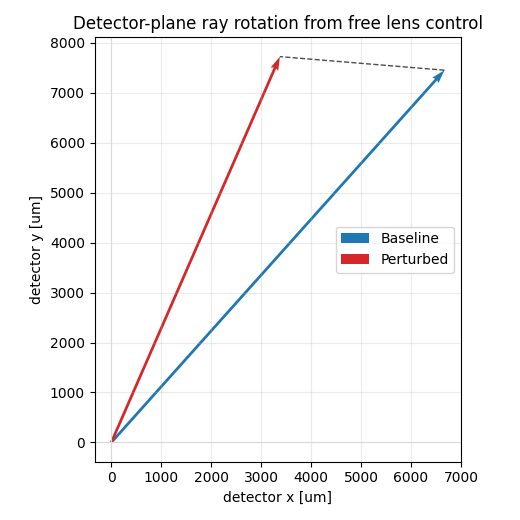

In [36]:
from dataclasses import replace
from temgym_core.components import ElectromagneticLens
from temgym_core.constants import compute_Rc_from_voltage

M_cum, labels = solve_model_with_z(ray0, column, names=column_names)[1:3]
M_cum = np.asarray(M_cum)
s_idx = max(i for i, lbl in enumerate(labels) if lbl == sample_name)
d_idx = max(i for i, lbl in enumerate(labels) if lbl == detector_name)
M_base = M_cum[d_idx] @ np.linalg.inv(M_cum[s_idx])
A_base = np.asarray(M_base)[0:2, 0:2]
theta_base = float(np.arctan2(A_base[1, 0] - A_base[0, 1], A_base[0, 0] + A_base[1, 1]))

sample_z, detector_z = float(sample.z), float(detector.z)
cands = [
    (i, comp, name)
    for i, (comp, name) in enumerate(zip(column, column_names))
    if isinstance(comp, ElectromagneticLens) and sample_z < float(comp.z) < detector_z
]
assert cands, "No post-sample electromagnetic lens found."
proj = [c for c in cands if "proj" in str(c[2]).lower() or "projector" in str(c[2]).lower()]
lens_idx, lens0, lens_name = proj[0] if proj else cands[0]

delta_current = 0.2
column_pert = list(column)
column_pert[lens_idx] = replace(lens0, current=float(lens0.current) + delta_current)

M_cum_p, labels_p = solve_model_with_z(ray0, column_pert, names=column_names)[1:3]
M_cum_p = np.asarray(M_cum_p)
s_idx_p = max(i for i, lbl in enumerate(labels_p) if lbl == sample_name)
d_idx_p = max(i for i, lbl in enumerate(labels_p) if lbl == detector_name)
M_pert = M_cum_p[d_idx_p] @ np.linalg.inv(M_cum_p[s_idx_p])
A_pert = np.asarray(M_pert)[0:2, 0:2]
theta_pert = float(np.arctan2(A_pert[1, 0] - A_pert[0, 1], A_pert[0, 0] + A_pert[1, 1]))

observed_delta = float(np.arctan2(np.sin(theta_pert - theta_base), np.cos(theta_pert - theta_base)))
expected_delta = float(compute_Rc_from_voltage(voltage) * lens0.turns * delta_current)
assert abs(observed_delta) > 1e-8, "Perturbation produced negligible rotation."
np.testing.assert_allclose(observed_delta, expected_delta, rtol=2e-2, atol=1e-8)

v0 = np.array([1e-7, 0.0])
v_base = A_base @ v0
v_pert = A_pert @ v0

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.axhline(0.0, color="0.85", lw=0.8)
ax.axvline(0.0, color="0.85", lw=0.8)
ax.quiver(0, 0, v_base[0] * 1e6, v_base[1] * 1e6, angles="xy", scale_units="xy", scale=1, color="C0", label="Baseline")
ax.quiver(0, 0, v_pert[0] * 1e6, v_pert[1] * 1e6, angles="xy", scale_units="xy", scale=1, color="C3", label="Perturbed")
ax.plot([v_base[0] * 1e6, v_pert[0] * 1e6], [v_base[1] * 1e6, v_pert[1] * 1e6], "k--", lw=1.0, alpha=0.7)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("detector x [um]")
ax.set_ylabel("detector y [um]")
ax.set_title("Detector-plane ray rotation from free lens control")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()

print(f"Baseline theta:  {theta_base:+.6e} rad")
print(f"Perturbed theta: {theta_pert:+.6e} rad  (lens={lens_name}, delta_I={delta_current:+.3f} A)")
print(f"Delta: observed={observed_delta:+.6e} rad, expected={expected_delta:+.6e} rad")

## 9. High-tension wobble check (point source, 500 rays, 50k magnification)

This experiment uses a point source with 500 Gaussian sub-beams and compares detector intensity at nominal HT against a uniform high-tension wobble of ±250 V around 200 kV, with imaging magnification fixed at `mag = 50000.0`.

HT wobble experiment
  Rays                 : 500 (point source)
  Magnification (mag)  : 50000.0
  Voltage nominal      : 200000.0 V
  Voltage range        : [199750.22, 200249.60] V
  Centroid shift       : 803106.4493 nm
  Spot-size delta      : 1226621.3386 nm
  Relative image L2    : 3.960751e-01


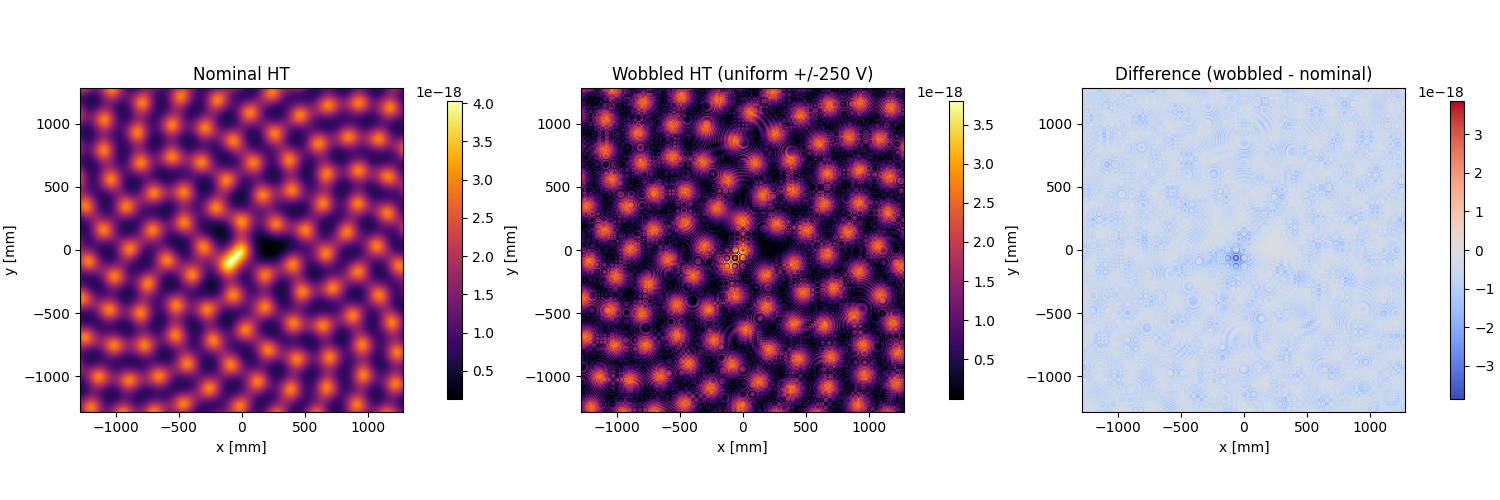

In [42]:
# --- HT wobble experiment settings ---
rng = np.random.default_rng(12345)
nominal_voltage = float(model.voltage)
ht_wobble_half_range = 250.0  # uniform +/- 250 V
n_wobble_rays = 500
mag_setting = 50000.0

# Keep condenser setting from earlier cells; force requested imaging magnification.
operating_modes_wobble = {
    "spot": float(operating_modes["spot"]),
    "mag": float(mag_setting),
}

# Build the column at 50k magnification.
optics_wobble = list(model.build_components(operating_modes_wobble))
ap_info_w = model.auxiliary["apertures"]["C_aperture"]
det_info_w = model.auxiliary["detector"]
samp_info_w = model.auxiliary["sample"]

aperture_wobble = SigmoidAperture(
    radius=ap_info_w["radii"][2],
    edge_width=ap_info_w["radii"][2] * 0.05,
    sharpness=10.0,
    z=ap_info_w["z"],
)
detector_wobble = Detector(
    z=det_info_w["z"],
    pixel_size=(det_info_w["pixel_size"], det_info_w["pixel_size"]),
    shape=(det_info_w["shape"][0], det_info_w["shape"][1]),
)
sample_wobble = Plane(z=samp_info_w["z"])
column_wobble = sorted(
    optics_wobble + [aperture_wobble, sample_wobble, detector_wobble],
    key=lambda c: float(c.z),
)

# Point-source beams: nominal vs uniformly wobbled high tension.
z_source_w = model.auxiliary.get("z_source", 0.0)
beam_nominal = point_source_wave(
    n=n_wobble_rays,
    half_angle=0.2e-3,
    waist=100e-9,
    voltage=nominal_voltage,
    z0=z_source_w,
)

voltage_samples = rng.uniform(
    nominal_voltage - ht_wobble_half_range,
    nominal_voltage + ht_wobble_half_range,
    size=n_wobble_rays,
)
beam_wobbled = point_source_wave(
    n=n_wobble_rays,
    half_angle=0.2e-3,
    waist=100e-9,
    voltage=jnp.asarray(voltage_samples),
    z0=z_source_w,
)

# Propagate both beams to detector.
_, _, beam_nominal_out, _ = trace_column(beam_nominal, column_wobble)
_, _, beam_wobbled_out, _ = trace_column(beam_wobbled, column_wobble)

field_nominal = evaluate_gaussians_gpu_kernel_wrapper(beam_nominal_out, detector_wobble)
field_wobbled = evaluate_gaussians_gpu_kernel_wrapper(beam_wobbled_out, detector_wobble)
I_nominal = np.array(jnp.abs(field_nominal) ** 2)
I_wobbled = np.array(jnp.abs(field_wobbled) ** 2)

# Intensity metrics for "image wobble": centroid shift + spot-size + image mismatch.
ny, nx = I_nominal.shape
pix = float(det_info_w["pixel_size"])
x = (np.arange(nx) - 0.5 * (nx - 1)) * pix
y = (np.arange(ny) - 0.5 * (ny - 1)) * pix
X, Y = np.meshgrid(x, y)

def image_moments(I):
    total = float(I.sum())
    cx = float((I * X).sum() / total)
    cy = float((I * Y).sum() / total)
    sx = float(np.sqrt((I * (X - cx) ** 2).sum() / total))
    sy = float(np.sqrt((I * (Y - cy) ** 2).sum() / total))
    return cx, cy, sx, sy

cx_n, cy_n, sx_n, sy_n = image_moments(I_nominal)
cx_w, cy_w, sx_w, sy_w = image_moments(I_wobbled)
centroid_shift = float(np.hypot(cx_w - cx_n, cy_w - cy_n))
size_change = float(np.hypot(sx_w - sx_n, sy_w - sy_n))
img_rel_l2 = float(np.linalg.norm(I_wobbled - I_nominal) / np.linalg.norm(I_nominal))

print("HT wobble experiment")
print(f"  Rays                 : {n_wobble_rays} (point source)")
print(f"  Magnification (mag)  : {mag_setting:.1f}")
print(f"  Voltage nominal      : {nominal_voltage:.1f} V")
print(f"  Voltage range        : [{voltage_samples.min():.2f}, {voltage_samples.max():.2f}] V")
print(f"  Centroid shift       : {centroid_shift * 1e9:.4f} nm")
print(f"  Spot-size delta      : {size_change * 1e9:.4f} nm")
print(f"  Relative image L2    : {img_rel_l2:.6e}")

# Show nominal, wobbled, and difference images in mm.
extent_mm = (
    np.array([
        -det_info_w["shape"][1] / 2,
         det_info_w["shape"][1] / 2,
        -det_info_w["shape"][0] / 2,
         det_info_w["shape"][0] / 2,
    ])
    * det_info_w["pixel_size"]
    * 1e3
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
im0 = axes[0].imshow(I_nominal, origin="lower", extent=extent_mm, cmap="inferno")
axes[0].set_title("Nominal HT")
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("y [mm]")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(I_wobbled, origin="lower", extent=extent_mm, cmap="inferno")
axes[1].set_title("Wobbled HT (uniform +/-250 V)")
axes[1].set_xlabel("x [mm]")
axes[1].set_ylabel("y [mm]")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

I_diff = I_wobbled - I_nominal
dmax = np.max(np.abs(I_diff))
im2 = axes[2].imshow(I_diff, origin="lower", extent=extent_mm, cmap="coolwarm", vmin=-dmax, vmax=dmax)
axes[2].set_title("Difference (wobbled - nominal)")
axes[2].set_xlabel("x [mm]")
axes[2].set_ylabel("y [mm]")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()